# Rigid bodies and joints

Notebook `python/Notebooks/tutorialRigidBody.ipynb` - the same model with the `Create` functions is
`python/Notebooks/tutorialRigidBodyCreate.ipynb`.

A double pendulum in 3D: two rigid bodies, the first attached to the ground with a revolute joint about $z$, the
second to the first with a revolute joint about $x$, under gravity. The joints are built from **markers** and
**joint objects**, which shows what the `Create` functions do and works for any kind of body, also flexible ones; the
outputs below each cell are those of the last run.

In [1]:
import exudyn as exu
from exudyn.utilities import InertiaCuboid, MarkerBodyRigid, GenericJoint, VObjectJointGeneric, \
                             ObjectJointRevoluteZ, VObjectJointRevoluteZ, SensorBody, RotationMatrixX, RotationMatrixY
from exudyn.interactive import ShowImage
import exudyn.graphics as graphics
import numpy as np

SC = exu.SystemContainer()
mbs = SC.AddSystem()

g = [0,-9.81,0]     #gravity
L = 1               #length
w = 0.1             #width
oGround = mbs.CreateGround(graphicsDataList=[graphics.CheckerBoard(point=[0.5,-1.6,0], normal=[0,1,0], size=3)])

The first link, a rigid body with its center of mass moved by $-L/4$ along its axis; `CreateRigidBody` adds a node, a
body and its gravity load. Its frame is at $[L/2,0,0]$, given as homogeneous transformation `exu.HT`.

In [2]:
iCube0 = InertiaCuboid(density=5000, sideLengths=[L,w,w]).Translated([-0.25*L,0,0])
graphicsBody0 = graphics.RigidLink(p0=[-0.5*L,0,0], p1=[0.5*L,0,0], axis0=[0,0,1], axis1=[0,0,0],
                                   radius=[0.5*w,0.5*w], thickness=w, width=[1.2*w,1.2*w], color=graphics.color.red)
b0 = mbs.CreateRigidBody(inertia=iCube0, referenceHT=exu.HT(translation=[0.5*L,0,0]), gravity=g,
                         graphicsDataList=[graphics.Basis(origin=iCube0.com, length=2*w), graphicsBody0])

A joint connects two **markers**, here two rigid body markers: on the ground at $[0,0,0]$ and on the body at its left
end. The joint axes are those of the markers' frames; a marker turns its frame by its `localHT`.

**Option 1** is the `GenericJoint`, which defines any joint with translations and rotations fixed or free - here all
but the rotation about $z$. **Option 2** is `ObjectJointRevoluteZ`, a free rotation about the local $z$-axis of
marker 0; any other axis is chosen by the rotation of the markers' `localHT`, e.g.
`MarkerBodyRigid(bodyNumber=b0, localHT=exu.HT().SetRotationY(0.5*np.pi))`.

In [3]:
markerGround = mbs.AddMarker(MarkerBodyRigid(bodyNumber=oGround, localPosition=[0,0,0]))
markerBody0J0 = mbs.AddMarker(MarkerBodyRigid(bodyNumber=b0, localPosition=[-0.5*L,0,0]))

#option 1:
oJoint0 = mbs.AddObject(GenericJoint(markerNumbers=[markerGround, markerBody0J0], constrainedAxes=[1,1,1,1,1,0],
                                     visualization=VObjectJointGeneric(axesRadius=0.2*w, axesLength=1.4*w)))
#option 2, the same joint:
#oJoint0 = mbs.AddObject(ObjectJointRevoluteZ(markerNumbers=[markerGround, markerBody0J0],
#                                             visualization=VObjectJointRevoluteZ(axisRadius=0.2*w, axisLength=1.4*w)))

A wrong marker position shows in the render window: with `localPosition=[-0.4*L,0,0]`, the two parts of the joint
would be drawn `0.1*L` apart.

The second link and its joint about $x$, again from two markers; the generic joint leaves the rotation about $x$ free:

In [4]:
graphicsBody1 = graphics.RigidLink(p0=[0,0,-0.5*L], p1=[0,0,0.5*L], axis0=[1,0,0], axis1=[0,0,0],
                                   radius=[0.06,0.05], thickness=0.1, width=[0.12,0.12], color=graphics.color.lightgreen)
b1 = mbs.CreateRigidBody(inertia=InertiaCuboid(density=5000, sideLengths=[0.1,0.1,1]),
                         referenceHT=exu.HT(translation=[L,0,0.5*L]), gravity=g, graphicsDataList=[graphicsBody1])

markerBody0J1 = mbs.AddMarker(MarkerBodyRigid(bodyNumber=b0, localPosition=[0.5*L,0,0]))
markerBody1J0 = mbs.AddMarker(MarkerBodyRigid(bodyNumber=b1, localPosition=[0,0,-0.5*L]))
oJoint1 = mbs.AddObject(GenericJoint(markerNumbers=[markerBody0J1, markerBody1J0], constrainedAxes=[1,1,1,0,1,1],
                                     visualization=VObjectJointGeneric(axesRadius=0.2*w, axesLength=1.4*w)))

sens1 = mbs.AddSensor(SensorBody(bodyNumber=b1, localPosition=[0,0,0.5*L], storeInternal=True,
                                 outputVariableType=exu.OutputVariableType.Position))
mbs.Assemble()
dof = mbs.ComputeSystemDegreeOfFreedom(verbose=True)

ODE2 coordinates          = 14
total constraints         = 14
redundant constraints     = 0
pure algebraic constraints= 2
degree of freedom         = 2


The model in its reference configuration, with the joint axes:

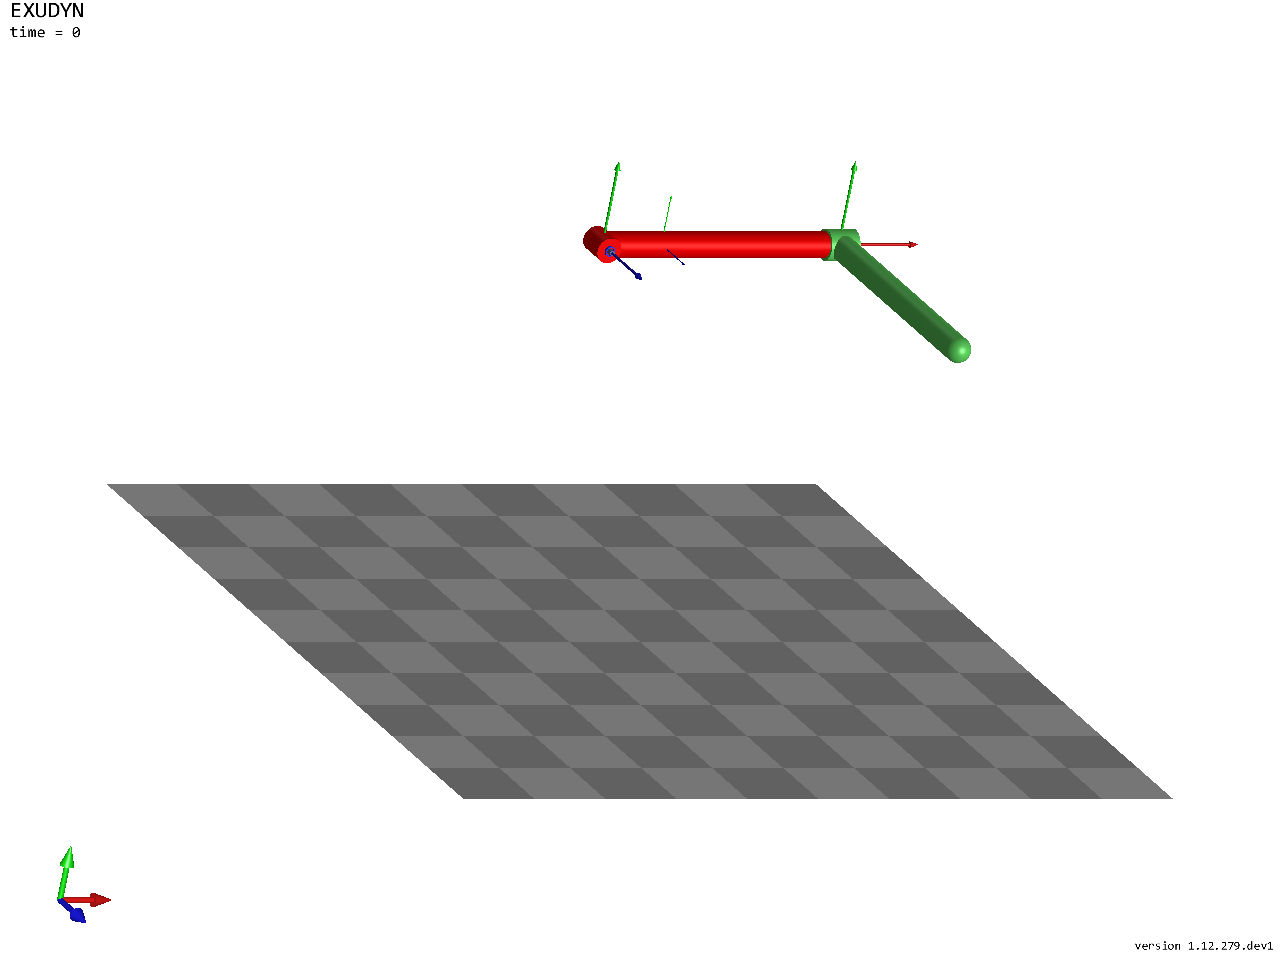

In [5]:
SC.visualizationSettings.nodes.show = False
SC.visualizationSettings.loads.show = False
SC.visualizationSettings.connectors.showJointAxes = True
SC.visualizationSettings.general.showSolverInformation = False
view = RotationMatrixX(-0.4) @ RotationMatrixY(-0.5)
image = ShowImage(SC, size=[1280,960], modelRotation=view)

Four seconds with the index 2 trapezoidal rule, and the tip position over time:

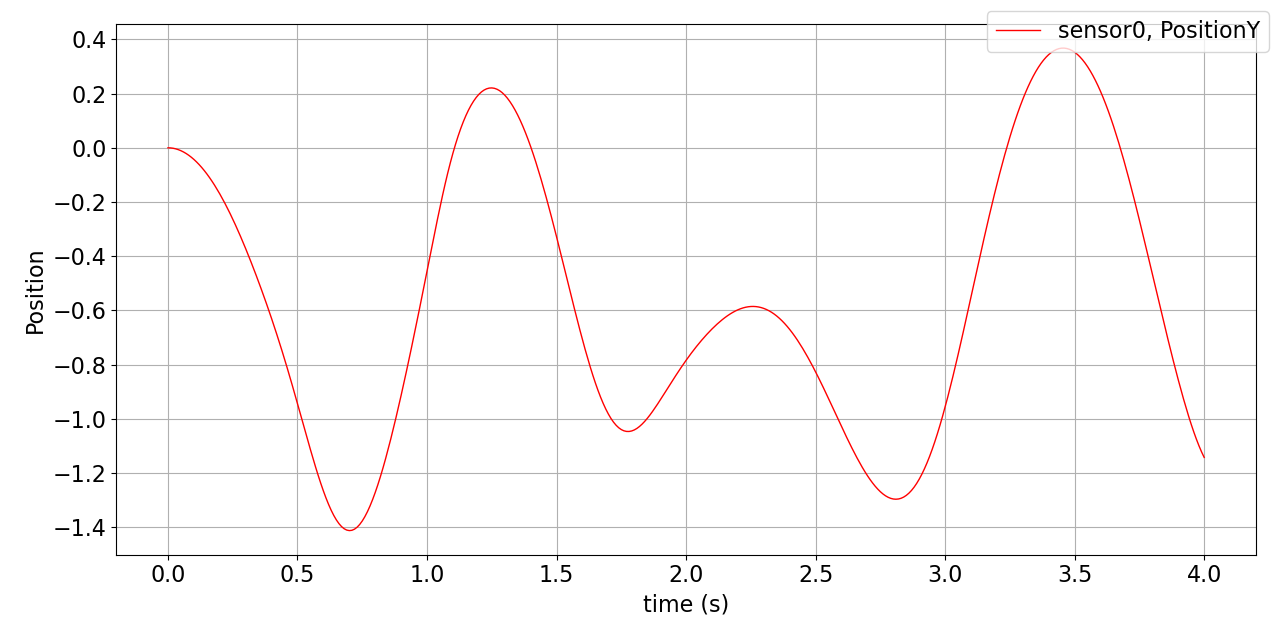

In [6]:
tEnd = 4
h = 1e-3
simulationSettings = exu.SimulationSettings()
simulationSettings.timeIntegration.numberOfSteps = int(tEnd/h)
simulationSettings.timeIntegration.endTime = tEnd
simulationSettings.solution.file.writePeriod = 0.005

mbs.SolveDynamic(simulationSettings=simulationSettings, solverType=exu.DynamicSolverType.TrapezoidalIndex2)
mbs.PlotSensor(sensorNumbers=[sens1], components=[1], closeAll=True)

In a script, `mbs.SolutionViewer()` shows the stored motion forward and backward in the render window.